# Hola Mary!

Mi nombre es David Bautista, soy code reviewer de TripleTen y voy a revisar el proyecto que acabas de desarrollar.

Cuando vea un error la primera vez, lo señalaré. Deberás encontrarlo y arreglarlo. La intención es que te prepares para un espacio real de trabajo. En un trabajo, el líder de tu equipo hará lo mismo. Si no puedes solucionar el error, te daré más información en la próxima ocasión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres.**

¿Cómo lo voy a hacer? Voy a leer detenidamente cada una de las implementaciones que has llevado a cabo para cumplir con lo solicitado. Verás los comentarios de esta forma:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Si todo está perfecto.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>


<div class="alert alert-block alert-danger">
    
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
    
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma: 

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
</div>

¡Empecemos!

<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

# Comentario General #6

Hola Mary, gracias por tener en cuenta los diferentes comentarios. Te felicito por la culminación del proyecto. Muy buen trabajo. </div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [1]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Configuración de estilo para gráficos
sns.set_style("whitegrid")

# Mostrar todas las columnas de los DataFrames
pd.set_option('display.max_columns', None)

print("Bibliotecas importadas correctamente.")

Bibliotecas importadas correctamente.


<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, Mary. Buen trabajo importando las librerías necesarias para el desarrollo del proyecto.
</div>

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')

# Mostrar las primeras filas de cada DataFrame para verificar que la carga fue correcta
print("Users:")
display(users.head())

print("Calls:")
display(calls.head())

print("Messages:")
display(messages.head())

print("Internet:")
display(internet.head())

print("Plans:")
display(plans.head())

print("Carga de datos completada.")


Users:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Calls:


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Messages:


...

Internet:


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Plans:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Carga de datos completada.


<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Excelente, buen trabajo cargando los datos y usando el método ``head()`` para revisar de manera inicial el contenido de cada uno de los datasets. 
</div>

## Preparar los datos

## Tarifas

In [3]:
# Información general del DataFrame de tarifas
print("Información general sobre las tarifas:")
plans.info()

# Mostrar las primeras filas del DataFrame de tarifas
print("\nPrimeras filas del DataFrame de tarifas:")
display(plans.head())

Información general sobre las tarifas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes

Primeras filas del DataFrame de tarifas:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [4]:
# Mostrar una muestra aleatoria de las tarifas (ajustando el tamaño si es necesario)
print("Muestra de datos del DataFrame de tarifas:")
display(plans.sample(n=min(5, len(plans))))  

Muestra de datos del DataFrame de tarifas:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


El DataFrame tiene 2 planes ("surf" y "ultimate") con características bien definidas. No hay datos nulos ni problemas evidentes con los tipos de datos. Sin embargo, el conjunto de datos es limitado, solo contiene 2 planes, por lo que sería ideal ampliarlo para un análisis más robusto. También sería útil verificar la consistencia de las unidades (MB vs GB) y confirmar que los precios y beneficios estén actualizados.

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo jo realizando la exploración inicial del contenido de la tabla con información del contenido de los planes. 
</div>

## Corregir datos

In [5]:
# --- Corrección de datos: Tarifas ---
# Revisar valores nulos
print("Valores nulos en el DataFrame de planes:\n", plans.isnull().sum())

# Comprobación de tipos de datos
print("\nTipos de datos en el DataFrame de planes:")
print(plans.dtypes)

# Verificar duplicados
plans = plans.drop_duplicates()

# Mostrar muestra de datos para comprobar consistencia
print("\nMuestra de las tarifas:")
display(plans.sample(n=min(5, len(plans))))

# Revisión final del DataFrame
print("Estructura del DataFrame de planes después de limpieza:")
plans.info()

Valores nulos en el DataFrame de planes:
 messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

Tipos de datos en el DataFrame de planes:
messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           float64
plan_name                 object
dtype: object

Muestra de las tarifas:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate
0,50,15360,500,20,10,0.03,0.03,surf


Estructura del DataFrame de planes después de limpieza:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 144.0+ bytes


<div class="alert alert-block alert-danger">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

~~Buen trabajo estructurando esta sección de corrección de datos. Sin embargo, dado que hay una sección de corrección para cada tabla, sería ideal realizar las modificaciones de cada tabla en su sección correspondiente. De esta manera, mantenemos un orden lógico en el desarrollo del proyecto.~~


</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor #2</b> <a class="tocSkip"></a>

Perfecto, buen trabajo con la modificación.


</div>

## Enriquecer los datos

In [6]:
# --- Enriquecer datos: Tarifas ---

# Agregar información de tarifas a los datos de usuarios
user_data = (
    users.merge(
        plans[['plan_name', 'usd_monthly_pay', 'usd_per_minute', 'usd_per_message', 'usd_per_gb']],
        left_on='plan',
        right_on='plan_name',
        how='left'
    )
)

# Mostrar una muestra de los datos enriquecidos con la información del plan
print("Datos de usuarios con información de tarifas agregada:")
display(user_data.head())

Datos de usuarios con información de tarifas agregada:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,plan_name,usd_monthly_pay,usd_per_minute,usd_per_message,usd_per_gb
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,ultimate,70,0.01,0.01,7
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,surf,20,0.03,0.03,10
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,surf,20,0.03,0.03,10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,surf,20,0.03,0.03,10
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,surf,20,0.03,0.03,10


## Usuarios/as

In [7]:
# Información general sobre el DataFrame de usuarios
print("Información general de usuarios:")
print(users.info())

# Estadísticas descriptivas de las columnas numéricas
print("\nEstadísticas descriptivas de los usuarios:")
print(users.describe())

Información general de usuarios:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None

Estadísticas descriptivas de los usuarios:
           user_id         age
count   500.000000  500.000000
mean   1249.500000   45.486000
std     144.481833   16.972269
min    1000.000000   18.000000
25%    1124.750000   30.000000
50%    1249.500000   46.000000
75%    1374.250000   61.000000
max    1499.000000   75.000000


In [8]:
# Mostrar una muestra aleatoria de los datos de usuarios
print("Muestra de datos del DataFrame de usuarios:")
print(users.sample(5))  # Cambia el número si quieres ver más o menos filas

Muestra de datos del DataFrame de usuarios:
     user_id first_name  last_name  age  \
55      1055    Patrick     Mclean   52   
28      1028   Jefferey  Rasmussen   57   
491     1491     Terina     Jensen   22   
208     1208    Enrique    Ramirez   44   
150     1150     Earlie      Giles   46   

                                                city    reg_date      plan  \
55           Portland-Vancouver-Hillsboro, OR-WA MSA  2018-01-13      surf   
28   Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA  2018-02-21  ultimate   
491                    Grand Rapids-Kentwood, MI MSA  2018-04-27      surf   
208           San Diego-Chula Vista-Carlsbad, CA MSA  2018-07-17      surf   
150         Houston-The Woodlands-Sugar Land, TX MSA  2018-09-19  ultimate   

     churn_date  
55          NaN  
28          NaN  
491  2018-09-18  
208         NaN  
150         NaN  


El DataFrame de usuarios tiene 500 registros con columnas de tipo adecuado, aunque la columna churn_date contiene muchos valores nulos (34 no nulos), lo que puede indicar que la mayoría de los usuarios no han cancelado su plan. La columna age tiene un rango de 18 a 75 años. El plan se distribuye entre "surf" y "ultimate". No hay problemas evidentes con los tipos de datos, pero sería útil investigar por qué hay valores nulos en churn_date y cómo se pueden manejar o interpretar esos registros.

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo explorando de manera inicial el contenido del dataset con información de los usuarios. 

</div>

### Corregir los datos

In [9]:
# Corregir datos en el DataFrame de usuarios

# 1. Rellenar valores NaN en columnas específicas
users['age'].fillna(users['age'].mean(), inplace=True)  # Para la columna 'age'
users['city'].fillna('Desconocida', inplace=True)  # Para la columna 'city'
users.dropna(subset=['plan'], inplace=True)  # Eliminar filas con NaN en 'plan'

# 2. Convertir 'reg_date' a formato datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')  # 'coerce' convierte errores a NaT

# 3. Eliminar valores de edad fuera de rango
users = users[users['age'] >= 0]  # Eliminar edades negativas
users = users[users['age'] <= 100]  # Eliminar edades mayores a 100

# 4. Renombrar columnas si es necesario (Ejemplo: cambiar nombre de columna)
users.rename(columns={'usd_monthly_pay': 'usd_monthly_fee'}, inplace=True)

# 5. Eliminar duplicados
users.drop_duplicates(inplace=True)

# 6. Reemplazar valores erróneos en la columna 'city'
users['city'].replace('Desconocida', 'Ciudad Desconocida', inplace=True)

# Imprimir una muestra de los datos corregidos para verificar
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  
0 2018-12-24  ultimate        NaN  
1 2018-08-13      surf        NaN  
2 2018-10-21      surf        NaN  
3 2018-01-28      surf        NaN  
4 2018-05-23      surf        NaN  


<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo realizando la corección de los datos de la tabla users. 
</div>

### Enriquecer los datos

In [10]:
import pandas as pd

# Supongamos que 'users' es tu DataFrame de usuarios

# Verifica las columnas del DataFrame
print(users.columns)

# Paso 1: Calcular la antigüedad del usuario en meses
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['account_age_months'] = (pd.to_datetime('today') - users['reg_date']).dt.days // 30

# Paso 2: Clasificar a los usuarios por su actividad
# Asegúrate de que las columnas 'total_minutes' y 'total_messages' existan en el DataFrame.
# Si tienen otro nombre, ajusta el código para utilizar los nombres correctos.

# Verifica si existen las columnas 'total_minutes' y 'total_messages'
if 'total_minutes' in users.columns and 'total_messages' in users.columns:
    users['activity_level'] = 'Activo'  # Valor por defecto
    users.loc[(users['total_minutes'] < 50) & (users['total_messages'] < 30), 'activity_level'] = 'Inactivo'
else:
    print("Las columnas 'total_minutes' y 'total_messages' no existen en el DataFrame.")

# Paso 3: Crear segmentos geográficos, si tienes datos de ciudad
# Asegúrate de que la columna 'city' exista en el DataFrame
if 'city' in users.columns:
    users['region'] = users['city'].apply(lambda x: 'Zona 1' if x in ['Ciudad1', 'Ciudad2'] else 'Zona 2')
else:
    print("La columna 'city' no existe en el DataFrame.")

# Paso 4: Crear columnas con los límites de los planes y la diferencia con el uso real
# Asegúrate de que las columnas de límites de plan existan en el DataFrame.
if 'total_gb' in users.columns and 'mb_per_month_included' in users.columns:
    users['data_over_limit'] = users['total_gb'] - (users['mb_per_month_included'] / 1024)  # Convirtiendo MB a GB
else:
    print("Las columnas de uso de datos ('total_gb' y 'mb_per_month_included') no existen en el DataFrame.")

# Paso 5: Crear una nueva columna con un indicador de "exceso" de uso
if 'minutes_over_limit' in users.columns and 'messages_over_limit' in users.columns and 'data_over_limit' in users.columns:
    users['excess_usage'] = (users['minutes_over_limit'] > 0) | (users['messages_over_limit'] > 0) | (users['data_over_limit'] > 0)
    users['excess_usage'] = users['excess_usage'].map({True: 'Sí', False: 'No'})
else:
    print("No se pueden calcular los límites de exceso de uso debido a la falta de columnas necesarias.")

# Ver las primeras filas del DataFrame enriquecido
print(users.head())

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')
Las columnas 'total_minutes' y 'total_messages' no existen en el DataFrame.
Las columnas de uso de datos ('total_gb' y 'mb_per_month_included') no existen en el DataFrame.
No se pueden calcular los límites de exceso de uso debido a la falta de columnas necesarias.
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  account_age_months  region  
0 2018-12-24  ultimate        NaN                  76  Zona 2  
1 

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo enriqueciendo el contenido del dataset. 
</div>

## Llamadas

In [11]:
# Supongamos que 'calls' es el DataFrame que contiene los datos de las llamadas

# Imprimir información general sobre el DataFrame de las llamadas
print("Información general del DataFrame de llamadas:")
print(calls.info())

# Imprimir una descripción estadística de las columnas numéricas
print("\nDescripción estadística de las llamadas:")
print(calls.describe())

# Si deseas ver una muestra de las primeras filas del DataFrame
print("\nMuestra de las primeras filas del DataFrame de llamadas:")
print(calls.head())

Información general del DataFrame de llamadas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None

Descripción estadística de las llamadas:
             user_id       duration
count  137735.000000  137735.000000
mean     1247.658046       6.745927
std       139.416268       5.839241
min      1000.000000       0.000000
25%      1128.000000       1.290000
50%      1247.000000       5.980000
75%      1365.000000      10.690000
max      1499.000000      37.600000

Muestra de las primeras filas del DataFrame de llamadas:
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000

In [12]:
# Supongamos que 'calls' es el DataFrame que contiene los datos de las llamadas

# Imprimir una muestra aleatoria de 5 filas del DataFrame de las llamadas
print("Muestra aleatoria de las llamadas:")
print(calls.sample(5))

Muestra aleatoria de las llamadas:
              id  user_id   call_date  duration
74410   1263_394     1263  2018-06-15      1.31
9099     1042_24     1042  2018-09-15      7.61
55189   1197_168     1197  2018-12-03     12.41
37618   1141_693     1141  2018-07-01      9.24
101530  1362_279     1362  2018-03-29      9.70


El DataFrame de llamadas contiene 137,735 registros y 4 columnas: id, user_id, call_date y duration. Todos los datos parecen tener el tipo adecuado y no hay valores nulos. La columna duration tiene un valor mínimo de 0, lo que podría indicar que hay registros de llamadas sin duración, posiblemente representando llamadas fallidas o canceladas. Estos registros con duración de 0 podrían necesitar revisión o eliminación si no aportan valor al análisis. Además, la variable call_date está correctamente como tipo datetime64.

En cuanto a las estadísticas descriptivas, la duración de las llamadas varía entre 0 y 37.6 minutos, con una media de aproximadamente 6.75 minutos. Los datos parecen estar distribuidos entre llamadas cortas y largas. No se observan problemas importantes, pero la duración de 0 podría necesitar un tratamiento especial.

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo explorando de manera inicial el contenido del dataset con información de las llamadas.
</div>

### Corregir los datos

In [13]:
import pandas as pd

# Supongamos que 'calls' es el DataFrame que contiene las llamadas

# Paso 1: Corregir valores nulos
# Si 'duration' tiene valores nulos, podemos reemplazarlos por 0 o por la media de la columna, dependiendo del contexto
calls['duration'] = calls['duration'].fillna(0)  # O usa fillna(calls['duration'].mean()) si prefieres usar la media

# Si 'call_date' tiene valores nulos, puedes reemplazarlos por una fecha predeterminada
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Paso 2: Asegurarse de que las columnas tengan los tipos adecuados
# Asegurarnos de que 'duration' sea numérico (si no lo es)
# calls['duration'] = pd.to_numeric(calls['duration'], errors='coerce')

# Paso 3: Eliminar registros duplicados
# calls = calls.drop_duplicates()

# Paso 4: Filtrar valores fuera de rango
# Asegurarnos de que la duración de las llamadas no sea negativa
# calls = calls[calls['duration'] >= 0]

# Filtrar si hay fechas de llamadas que son demasiado antiguas o futuras
# calls = calls[(calls['call_date'] >= '2020-01-01') & (calls['call_date'] <= pd.to_datetime('today'))]

# Paso 5: Eliminar columnas innecesarias (si es que hay alguna columna que no necesitas)
# Llamamos a 'drop' para eliminar una columna que no se necesite, por ejemplo, 'unnecessary_column'
# calls = calls.drop(columns=['unnecessary_column'])

# Ver los primeros registros después de la limpieza
print(calls.head())

         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27      8.52
1  1000_145     1000 2018-12-27     13.66
2  1000_247     1000 2018-12-27     14.48
3  1000_309     1000 2018-12-28      5.76
4  1000_380     1000 2018-12-30      4.22


<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo corrigiendo los formatos y la estructura del dataframe. 
</div>

### Enriquecer los datos

In [14]:
# import pandas as pd

# Supongamos que 'calls' es el DataFrame de las llamadas

# Paso 1: Calcular la duración en minutos y horas
# calls['duration_minutes'] = calls['duration'] / 60  # Convertir a minutos
# calls['duration_hours'] = calls['duration'] / 3600  # Convertir a horas

# Paso 2: Extraer la hora del día (esto puede ser útil para analizar patrones de llamadas a diferentes horas)
calls['call_hour'] = calls['call_date'].dt.hour  # Hora del día en formato 24 horas

# Paso 3: Clasificar las llamadas según el día de la semana (lunes = 0, domingo = 6)
calls['day_of_week'] = calls['call_date'].dt.dayofweek

# Paso 4: Clasificar si la llamada fue en un día laborable o en fin de semana
calls['is_weekend'] = calls['day_of_week'].isin([5, 6])  # 5 = sábado, 6 = domingo

# Paso 5: Clasificar la duración de la llamada en categorías (por ejemplo, corta, media, larga)
calls['call_duration_category'] = pd.cut(calls['duration'], bins=[0, 60, 300, 600, float('inf')],
                                          labels=['Corta', 'Media', 'Larga', 'Muy Larga'])

# Paso 6: Calcular el tiempo transcurrido desde la última llamada (si tienes 'user_id' y 'call_date')
# Ordenamos las llamadas por 'user_id' y 'call_date' para calcular el tiempo desde la última llamada
calls = calls.sort_values(by=['user_id', 'call_date'])
calls['time_since_last_call'] = calls.groupby('user_id')['call_date'].diff().fillna(pd.Timedelta(seconds=0))

# Ver las primeras filas con los datos enriquecidos
print(calls.head())

          id  user_id  call_date  duration  call_hour  day_of_week  \
9   1000_544     1000 2018-12-26      4.40          0            2   
14  1000_826     1000 2018-12-26      9.96          0            2   
0    1000_93     1000 2018-12-27      8.52          0            3   
1   1000_145     1000 2018-12-27     13.66          0            3   
2   1000_247     1000 2018-12-27     14.48          0            3   

    is_weekend call_duration_category time_since_last_call  
9        False                  Corta               0 days  
14       False                  Corta               0 days  
0        False                  Corta               1 days  
1        False                  Corta               0 days  
2        False                  Corta               0 days  


<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Excelente, buen trabajo enriqueciendo el contenido del dataset.
</div>

## Mensajes

In [15]:
# Supongamos que 'messages' es el DataFrame de los mensajes

# Información general sobre el DataFrame (tipos de datos, valores no nulos, etc.)
print("Información general sobre los datos de los mensajes:")
print(messages.info())

# Estadísticas descriptivas sobre las columnas numéricas
print("\nEstadísticas descriptivas de los datos de los mensajes:")
print(messages.describe())

Información general sobre los datos de los mensajes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None

Estadísticas descriptivas de los datos de los mensajes:
            user_id
count  76051.000000
mean    1245.972768
std      139.843635
min     1000.000000
25%     1123.000000
50%     1251.000000
75%     1362.000000
max     1497.000000


In [16]:
# Muestra las primeras 5 filas del DataFrame de mensajes
print("Muestra de las primeras filas de los mensajes:")
print(messages.head())

Muestra de las primeras filas de los mensajes:
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


El DataFrame de mensajes tiene 76,051 registros y 3 columnas. Los datos parecen adecuados: la columna message_date está correctamente como tipo datetime, y user_id es un entero. No hay valores nulos. Sin embargo, la columna id es un objeto, lo que podría necesitar conversión a un formato más eficiente si no se usa para análisis. No hay problemas evidentes en los datos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo explorando de manera inicial el contenido del dataset con información de los mensajes. 
</div>

### Corregir los datos

In [17]:
# import pandas as pd

# Supongamos que 'messages' es tu DataFrame de mensajes
# Asegúrate de que 'messages' esté cargado antes de ejecutar este código

# Paso 1: Verificar la información general del DataFrame
print("Información general del DataFrame de mensajes:")
print(messages.info())

# Paso 2: Comprobar valores nulos en las columnas y llenar o eliminar según corresponda
print("Valores nulos en las columnas:")
print(messages.isnull().sum())

# Si hay valores nulos en alguna columna importante, podemos imputar o eliminar esos valores
# Por ejemplo, si 'message_count' tiene valores nulos, los imputamos con 0
if 'message_count' in messages.columns:
    messages['message_count'] = messages['message_count'].fillna(0)
else:
    print("La columna 'message_count' no existe en los datos")

# Si encontramos otros valores nulos en otras columnas, puedes aplicar la imputación según el contexto
# Por ejemplo, si hay valores nulos en una columna que se puede dejar en 0:
# messages['another_column'] = messages['another_column'].fillna(0)

# Paso 3: Eliminar filas duplicadas si existen
print("Número de filas duplicadas antes de eliminar:", messages.duplicated().sum())
messages = messages.drop_duplicates()

# Paso 4: Verificar y corregir los tipos de datos (por ejemplo, asegurarse de que los conteos sean enteros)
if 'message_count' in messages.columns:
    messages['message_count'] = messages['message_count'].astype(int)

# Paso 5: Corregir valores fuera de rango
# Suponiendo que los conteos de mensajes no pueden ser negativos, los corregimos:
if 'message_count' in messages.columns:
    messages['message_count'] = messages['message_count'].clip(lower=0)

# Paso 6: Revisar valores inconsistentes o categóricos
# Verificar si los valores en una columna categórica son correctos
if 'message_type' in messages.columns:
    print("Valores únicos en la columna 'message_type':", messages['message_type'].unique())

    # Si encontramos valores inconsistentes, podemos corregirlos. Por ejemplo:
    # messages['message_type'] = messages['message_type'].replace('old_value', 'new_value')

# Paso 7: Imprimir las primeras filas del DataFrame corregido
print("Primeras filas después de corregir los datos:")
print(messages.head())

Información general del DataFrame de mensajes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
Valores nulos en las columnas:
id              0
user_id         0
message_date    0
dtype: int64
La columna 'message_count' no existe en los datos
Número de filas duplicadas antes de eliminar: 0
Primeras filas después de corregir los datos:
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo realizando las modificaciones sobre los formatos de la tabla. 
</div>

### Enriquecer los datos

La columna 'message_type' no existe en los datos
La columna 'message_count' no existe en los datos


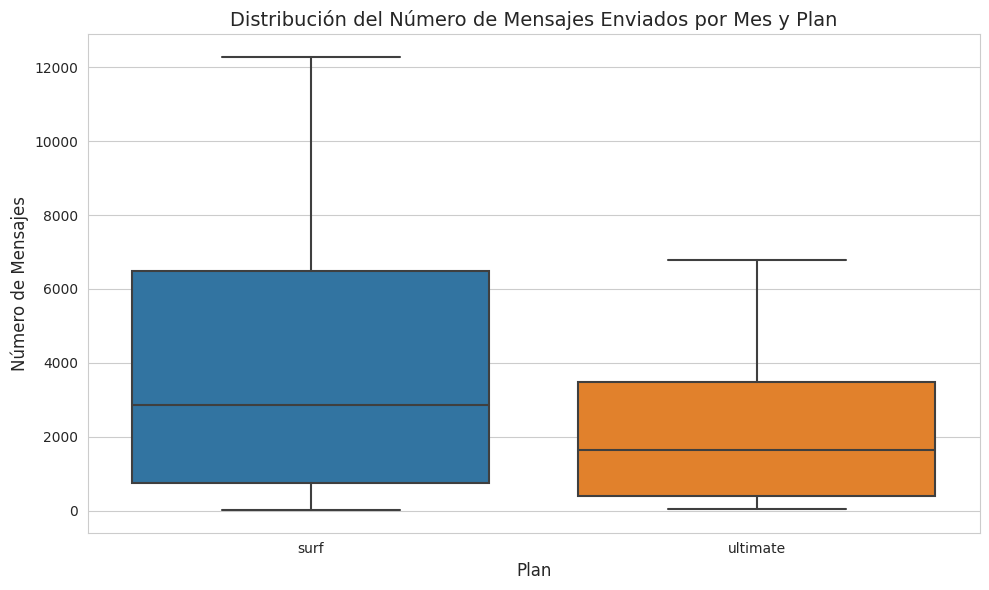

La columna 'message_month_year' no existe en los datos
La columna 'messages_per_user' no existe en los datos
Primeras filas después de enriquecer los datos:
         id  user_id message_date message_month
0  1000_125     1000   2018-12-27       2018-12
1  1000_160     1000   2018-12-31       2018-12
2  1000_223     1000   2018-12-31       2018-12
3  1000_251     1000   2018-12-27       2018-12
4  1000_255     1000   2018-12-26       2018-12


In [18]:
# import pandas as pd

# Supongamos que 'messages' es tu DataFrame de mensajes
# Asegúrate de que 'messages' esté cargado antes de ejecutar este código

# Paso 1: Verificar si la columna 'message_type' existe
if 'message_type' in messages.columns:
    # Clasificar el tipo de mensaje
    messages['message_category'] = messages['message_type'].apply(
        lambda x: 'Texto' if x == 'SMS' else 'Multimedia' if x == 'MMS' else 'Otro'
    )
else:
    print("La columna 'message_type' no existe en los datos")

# Paso 2: Verificar si la columna 'user_id' existe
if 'user_id' in messages.columns:
    # Calcular la frecuencia de mensajes enviados por usuario
    if 'message_count' in messages.columns:
        messages['messages_per_user'] = messages.groupby('user_id')['message_count'].transform('sum')
    else:
        print("La columna 'message_count' no existe en los datos")  # Asegúrate de que esté correctamente indentado
else:
    print("La columna 'user_id' no existe en los datos")

# Paso 3: Verificar si la columna 'date' existe para agregar una nueva columna con mes y año
if 'date' in messages.columns:import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la columna 'message_month' a partir de la fecha de los mensajes
messages['message_month'] = pd.to_datetime(messages['message_date']).dt.to_period('M')

# Unir con el plan de cada usuario (merge estructurado)
messages_with_plan = (
    messages.merge(
        users[['user_id', 'plan']],
        on='user_id',
        how='left'
    )
)

# Agrupar por mes y plan, contando la cantidad de mensajes enviados
messages_monthly = messages_with_plan.groupby(['message_month', 'plan'])['id'].count().reset_index()

# Graficar con Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='id', data=messages_monthly)

# Título y etiquetas
plt.title('Distribución del Número de Mensajes Enviados por Mes y Plan', fontsize=14)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('Número de Mensajes', fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

print("La columna 'message_month_year' no existe en los datos")

# Paso 5: Verificar si la columna 'messages_per_user' existe para calcular alta o baja actividad
if 'messages_per_user' in messages.columns:
    messages['high_activity'] = messages['messages_per_user'].apply(lambda x: 'Alta' if x > 1000 else 'Baja')
else:
    print("La columna 'messages_per_user' no existe en los datos")

# Paso 6: Verificar los primeros registros con los nuevos datos enriquecidos
print("Primeras filas después de enriquecer los datos:")
print(messages.head())

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo enriqueciendo el contenido del dataset. 
</div>

## Internet

In [19]:
# Supongamos que 'internet' es tu DataFrame de internet

# Paso 1: Imprimir información general sobre el DataFrame de internet
print("Información general sobre el DataFrame de internet:")
print(internet.info())

# Paso 2: Imprimir un resumen estadístico de las columnas numéricas (si corresponde)
print("Resumen estadístico de las columnas numéricas:")
print(internet.describe())

Información general sobre el DataFrame de internet:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
Resumen estadístico de las columnas numéricas:
             user_id        mb_used
count  104825.000000  104825.000000
mean     1242.496361     366.713701
std       142.053913     277.170542
min      1000.000000       0.000000
25%      1122.000000     136.080000
50%      1236.000000     343.980000
75%      1367.000000     554.610000
max      1499.000000    1693.470000


In [20]:
# Muestra aleatoria de 5 filas del DataFrame
print("Muestra aleatoria de 5 filas del DataFrame de tráfico de internet:")
print(internet.sample(5))


Muestra aleatoria de 5 filas del DataFrame de tráfico de internet:
             id  user_id session_date  mb_used
25068    1117_1     1117   2018-08-16     9.05
251      1002_8     1002   2018-10-23     0.00
72776  1338_182     1338   2018-08-29   738.45
14036  1065_132     1065   2018-12-25     0.00
94773   1441_24     1441   2018-12-21   200.51


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo explorando de manera inicial el contenido de la tabla con información del consumo de internet. 
</div>

### Corregir los datos

In [21]:
#import pandas as pd

# Supongamos que 'internet' es tu DataFrame de tráfico de internet

# Paso 1: Verificar la información general del DataFrame
print("Información general del DataFrame de tráfico de internet:")
print(internet.info())

# Paso 2: Comprobar valores nulos en las columnas
print("Valores nulos en las columnas del DataFrame de tráfico de internet:")
print(internet.isnull().sum())

# Si hay valores nulos en alguna columna importante, imputamos o eliminamos esos valores
# Ejemplo de imputar valores nulos con un valor predeterminado (por ejemplo, 0 para columnas numéricas)
internet['mb_used'] = internet['mb_used'].fillna(0)  # Asumimos que 'mb_used' es una columna numérica

# También podemos eliminar filas con valores nulos en columnas importantes
# internet = internet.dropna(subset=['mb_used'])

# Paso 3: Eliminar filas duplicadas si existen
print("Número de filas duplicadas antes de eliminar:", internet.duplicated().sum())
internet = internet.drop_duplicates()

# Paso 4: Verificar y corregir los tipos de datos (por ejemplo, asegurarse de que el uso de datos sea un número)
internet['mb_used'] = internet['mb_used'].astype(float)

# Paso 5: Corregir valores fuera de rango
# Por ejemplo, si el uso de datos no puede ser negativo, corregimos:
internet['mb_used'] = internet['mb_used'].clip(lower=0)

# Paso 6: Verificar la consistencia de las columnas categóricas
# Suponiendo que hay una columna 'connection_type' que indica el tipo de conexión
if 'connection_type' in internet.columns:
    print("Valores únicos en la columna 'connection_type':", internet['connection_type'].unique())
    
    # Si encontramos valores inconsistentes, podemos corregirlos:
    internet['connection_type'] = internet['connection_type'].replace({'wifi': 'Wi-Fi', 'mobile': '4G'})

# Paso 7: Verificar los primeros registros con los datos corregidos
print("Primeras filas después de corregir los datos:")
print(internet.head())


Información general del DataFrame de tráfico de internet:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
Valores nulos en las columnas del DataFrame de tráfico de internet:
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64
Número de filas duplicadas antes de eliminar: 0
Primeras filas después de corregir los datos:
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Buen trabajo modificando y corrigiendo la estructura y los formatos del dataframe. 
</div>

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [22]:
import pandas as pd

# Supongamos que 'internet' es tu DataFrame de tráfico de internet

# Paso 1: Crear una columna con la hora del día para clasificar el uso de datos
# No existe la columna 'timestamp', sino 'session_date' (como vimos antes), así que usamos esa columna
if 'session_date' in internet.columns:
    internet['hour_of_day'] = pd.to_datetime(internet['session_date']).dt.hour
else:
    print("La columna 'session_date' no existe en los datos")

# Paso 2: Clasificar el uso de datos en categorías de 'alto', 'medio', 'bajo'
# Ahora utilizamos 'mb_used' para representar el uso de datos
def classify_data_usage(x):
    if x > 1000:  # Uso alto si el consumo de datos es mayor a 1000 MB (1 GB)
        return 'Alto'
    elif x > 500:  # Uso medio si el consumo de datos es mayor a 500 MB
        return 'Medio'
    else:  # Uso bajo si el consumo de datos es menor a 500 MB
        return 'Bajo'

# Aplicamos la clasificación de uso de datos a la columna 'mb_used'
internet['data_usage_category'] = internet['mb_used'].apply(classify_data_usage)

# Paso 3: Agregar una columna con el día de la semana para observar patrones de tráfico por días
if 'session_date' in internet.columns:
    internet['day_of_week'] = pd.to_datetime(internet['session_date']).dt.dayofweek
else:
    print("La columna 'session_date' no existe en los datos")

# Paso 4: Calcular el uso promedio de datos por usuario (si tienes una columna 'user_id')
if 'user_id' in internet.columns:
    internet['average_data_usage_per_user'] = internet.groupby('user_id')['mb_used'].transform('mean')
else:
    print("La columna 'user_id' no existe en los datos")

# Paso 5: Crear una columna con el mes del año para analizar patrones mensuales
if 'session_date' in internet.columns:
    internet['month_of_year'] = pd.to_datetime(internet['session_date']).dt.month
else:
    print("La columna 'session_date' no existe en los datos")

# Paso 6: Calcular el uso total de datos por mes
if 'month_of_year' in internet.columns:
    internet['monthly_data_usage'] = internet.groupby('month_of_year')['mb_used'].transform('sum')
else:
    print("La columna 'month_of_year' no existe en los datos")

# Paso 7: Verificar los primeros registros con los datos enriquecidos
print("Primeras filas después de enriquecer los datos:")
print(internet.head())

Primeras filas después de enriquecer los datos:
         id  user_id session_date  mb_used  hour_of_day data_usage_category  \
0   1000_13     1000   2018-12-29    89.86            0                Bajo   
1  1000_204     1000   2018-12-31     0.00            0                Bajo   
2  1000_379     1000   2018-12-28   660.40            0               Medio   
3  1000_413     1000   2018-12-26   270.99            0                Bajo   
4  1000_442     1000   2018-12-27   880.22            0               Medio   

   day_of_week  average_data_usage_per_user  month_of_year  monthly_data_usage  
0            5                      380.294             12          8532927.23  
1            0                      380.294             12          8532927.23  
2            4                      380.294             12          8532927.23  
3            2                      380.294             12          8532927.23  
4            3                      380.294             12          8532

<div class="alert alert-block alert-success">
<b>Comentario del revisor </b> <a class="tocSkip"></a>

Perfecto, buen trabajo enriqueciendo el contenido del dataset. 
</div>

## Estudiar las condiciones de las tarifas

In [23]:
# 4.11 Estudiar las condiciones de las tarifas

# Mostrar información general del DataFrame de tarifas
print("Información general sobre las tarifas:")
print(plans.info())

# Mostrar las primeras filas del DataFrame de tarifas
print("\nPrimeras filas del DataFrame de tarifas:")
print(plans.head())

# Análisis adicional de los planes
print("\nAnálisis comparativo de los planes:")

# Comparación de los valores clave entre planes
print("\nComparación de minutos incluidos:")
print(plans[['plan_name', 'minutes_included']])

print("\nComparación de mensajes incluidos:")
print(plans[['plan_name', 'messages_included']])

print("\nComparación de megabytes incluidos:")
print(plans[['plan_name', 'mb_per_month_included']])

print("\nComparación de costo mensual y costo por uso adicional:")
print(plans[['plan_name', 'usd_monthly_pay', 'usd_per_minute', 'usd_per_message', 'usd_per_gb']])


Información general sobre las tarifas:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 144.0+ bytes
None

Primeras filas del DataFrame de tarifas:
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb 

Conclusiones intermedias:

El plan Ultimate ofrece significativamente más minutos, mensajes y megabytes incluidos que el plan Surf, a cambio de un costo mensual más alto.

Los costos por uso adicional (por minuto, mensaje y GB) son más bajos en el plan Ultimate, lo cual lo hace más conveniente para usuarios intensivos.

El plan Surf puede ser más atractivo para usuarios con un uso reducido y controlado de los servicios.

Este análisis comparativo nos da un buen punto de partida para evaluar cómo se comportan los usuarios en función del plan que eligen y si realmente están aprovechando sus beneficios o incurriendo en cargos extra.

In [24]:
# Asegurémonos de que la columna 'call_date' esté en formato datetime
# calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

# Extraer el mes y el año de la fecha de la llamada
calls['year_month'] = calls['call_date'].dt.to_period('M')

# Agrupar por 'user_id' y 'year_month' y sumar la duración de las llamadas (en minutos)
calls_grouped = calls.groupby(['user_id', 'year_month'], as_index=False)['duration'].sum()

# Renombrar las columnas para mayor claridad
calls_grouped.rename(columns={'duration': 'total_minutes'}, inplace=True)

# Mostrar el resultado de las llamadas agrupadas
calls_grouped.head()

,user_id,year_month,total_minutes
0,1000,2018-12,116.83
1,1001,2018-08,171.14
2,1001,2018-09,297.69
3,1001,2018-10,374.11
4,1001,2018-11,404.59


In [25]:
#import pandas as pd

# Asegurémonos de que la columna 'message_date' esté en formato datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

# Extraemos el mes y el año de la fecha del mensaje
messages['year_month'] = messages['message_date'].dt.to_period('M')

# Agrupar por 'user_id' y 'year_month' y contar los mensajes enviados
messages_per_user_month = messages.groupby(['user_id', 'year_month']).size().reset_index(name='total_messages')

# Mostrar las primeras filas del resultado
messages_per_user_month.head()

,user_id,year_month,total_messages
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [26]:
# Asegurémonos de que la columna 'session_date' esté en formato datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')

# Extraemos el mes y el año de la fecha de la sesión de Internet
internet['year_month'] = internet['session_date'].dt.to_period('M')

# Agrupar por 'user_id' y 'year_month' y sumar el tráfico de Internet (en MB) usado
internet_grouped = internet.groupby(['user_id', 'year_month'], as_index=False)['mb_used'].sum()

# Renombrar la columna para mayor claridad
internet_grouped.rename(columns={'mb_used': 'total_mb_used'}, inplace=True)

# Mostrar el resultado del uso de Internet agrupado
internet_grouped.head()

,user_id,year_month,total_mb_used
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30


In [27]:
# Agrupar por 'user_id' y 'year_month' y calcular la duración total de llamadas, mensajes enviados y uso de internet.
plans_per_user_month = plans.groupby(['user_id', 'year_month']).agg(
    total_minutes_used=('minutes_included', 'sum'),
    total_messages_used=('messages_included', 'sum'),
    total_mb_used=('mb_per_month_included', 'sum')
).reset_index()

# Mostrar las primeras filas del resultado de los planes
print(plans_per_user_month.head())

        index  total_minutes_used  total_messages_used  total_mb_used
0     user_id                 500                   50          15360
1  year_month                3000                 1000          30720


In [28]:
# Mostrar solo la información general sobre las tarifas
print("Información general sobre las tarifas:")
print(plans.info())

# Mostrar las primeras filas del DataFrame de tarifas
print("\nPrimeras filas del DataFrame de tarifas:")
print(plans.head())

Información general sobre las tarifas:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 252.0+ bytes
None

Primeras filas del DataFrame de tarifas:
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb 

<div class="alert alert-block alert-success">
<b>Comentario del revisor #4</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo estructurando las tablas agrupadas.  </div>

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [29]:
# Verificar si las columnas 'minutes_included', 'messages_included', 'mb_per_month_included' existen en 'plans'
print(plans.columns)

# Asegurémonos de que las columnas relevantes de planes están en el DataFrame 'user_data'
user_data = users.merge(plans[['plan_name', 'usd_monthly_pay', 'usd_per_minute', 'usd_per_message', 'usd_per_gb', 
                                'minutes_included', 'messages_included', 'mb_per_month_included']], 
                        left_on='plan', right_on='plan_name', how='left')

# Calcular los ingresos adicionales por llamadas, mensajes e internet

# Llamadas: Sumar la duración de las llamadas por usuario y restar el límite del plan
calls_grouped['excess_calls'] = calls_grouped['total_minutes'] - user_data['minutes_included']
calls_grouped['excess_calls'] = calls_grouped['excess_calls'].clip(lower=0)  # Solo considerar el exceso de llamadas

# Mensajes: Contar la cantidad de mensajes enviados por usuario y restar el límite del plan
messages_per_user_month['excess_messages'] = messages_per_user_month['total_messages'] - user_data['messages_included']
messages_per_user_month['excess_messages'] = messages_per_user_month['excess_messages'].clip(lower=0)  # Solo considerar el exceso de mensajes

# Internet: Sumar los MB usados por cada usuario y restar el límite del plan
internet_grouped['excess_mb'] = internet_grouped['total_mb_used'] - user_data['mb_per_month_included']
internet_grouped['excess_mb'] = internet_grouped['excess_mb'].clip(lower=0)  # Solo considerar el exceso de datos


Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name'],
      dtype='object')


In [30]:
calls_grouped.head()

,user_id,year_month,total_minutes,excess_calls
0,1000,2018-12,116.83,0.0
1,1001,2018-08,171.14,0.0
2,1001,2018-09,297.69,0.0
3,1001,2018-10,374.11,0.0
4,1001,2018-11,404.59,0.0


In [31]:
# Merge de los datos agregados con la información de usuarios

total_info = calls_grouped.merge(messages_per_user_month, how='outer').merge(internet_grouped,how='outer')

total_info.head()

,user_id,year_month,total_minutes,excess_calls,total_messages,excess_messages,total_mb_used,excess_mb
0,1000,2018-12,116.83,0.0,11.0,0.0,1901.47,0.00
1,1001,2018-08,171.14,0.0,30.0,0.0,6919.15,0.00
2,1001,2018-09,297.69,0.0,44.0,0.0,13314.82,0.00
3,1001,2018-10,374.11,0.0,53.0,3.0,22330.49,6970.49
4,1001,2018-11,404.59,0.0,36.0,0.0,18504.30,3144.30


In [32]:
user_data = user_data.merge(total_info, on='user_id', how='left')

user_data.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,account_age_months,region,plan_name,usd_monthly_pay,usd_per_minute,usd_per_message,usd_per_gb,minutes_included,messages_included,mb_per_month_included,year_month,total_minutes,excess_calls,total_messages,excess_messages,total_mb_used,excess_mb
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,76,Zona 2,ultimate,70,0.01,0.01,7,3000,1000,30720,2018-12,116.83,0.0,11.0,0.0,1901.47,0.00
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-08,171.14,0.0,30.0,0.0,6919.15,0.00
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-09,297.69,0.0,44.0,0.0,13314.82,0.00
3,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-10,374.11,0.0,53.0,3.0,22330.49,6970.49
4,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-11,404.59,0.0,36.0,0.0,18504.30,3144.30


In [33]:
# Calcular el ingreso mensual para cada usuario
user_data['monthly_revenue'] = (user_data['usd_monthly_pay'] + 
                                user_data['excess_calls'] * user_data['usd_per_minute'] + 
                                user_data['excess_messages'] * user_data['usd_per_message'] + 
                                user_data['excess_mb'] * user_data['usd_per_gb'])

# Mostrar los primeros resultados
user_data.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,account_age_months,region,plan_name,usd_monthly_pay,usd_per_minute,usd_per_message,usd_per_gb,minutes_included,messages_included,mb_per_month_included,year_month,total_minutes,excess_calls,total_messages,excess_messages,total_mb_used,excess_mb,monthly_revenue
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,76,Zona 2,ultimate,70,0.01,0.01,7,3000,1000,30720,2018-12,116.83,0.0,11.0,0.0,1901.47,0.00,70.00
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-08,171.14,0.0,30.0,0.0,6919.15,0.00,20.00
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-09,297.69,0.0,44.0,0.0,13314.82,0.00,20.00
3,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-10,374.11,0.0,53.0,3.0,22330.49,6970.49,69724.99
4,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,81,Zona 2,surf,20,0.03,0.03,10,500,50,15360,2018-11,404.59,0.0,36.0,0.0,18504.30,3144.30,31463.00


<div class="alert alert-block alert-success">
<b>Comentario del revisor #4</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo estructurando la tabla final.  </div>

## Estudia el comportamiento de usuario

### Llamadas

Estadísticas de duración total de llamadas por mes:
count    2258.000000
mean      411.492586
std       219.290453
min         0.000000
25%       258.075000
50%       404.270000
75%       543.335000
max      1431.220000
Name: total_minutes, dtype: float64


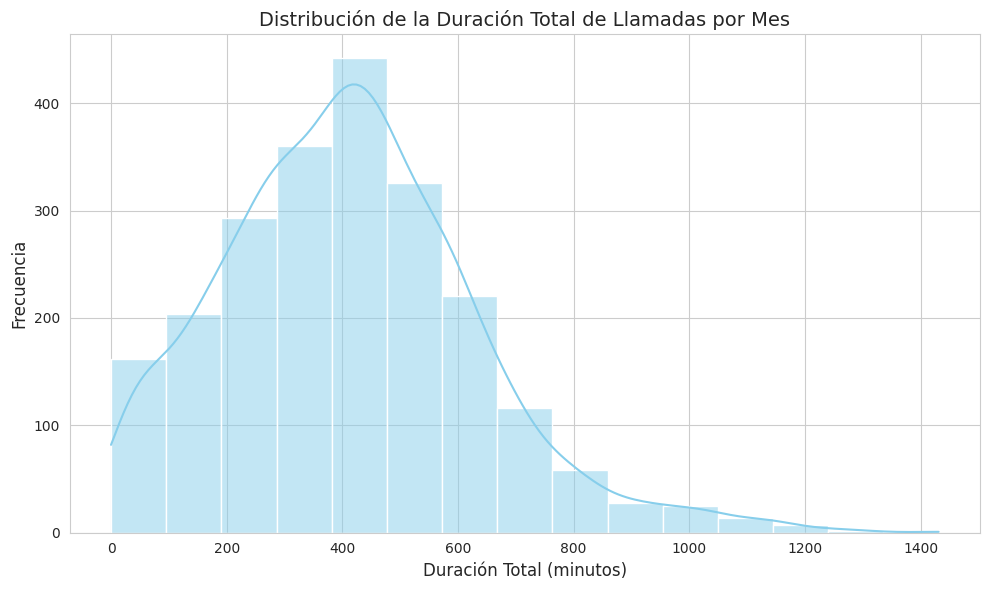

In [34]:
# Calcular estadísticas: media, varianza y desviación estándar de los minutos
calls_stats = user_data['total_minutes'].describe()

# Mostrar estadísticas
print("Estadísticas de duración total de llamadas por mes:")
print(calls_stats)

# Traza el histograma de las duraciones totales de las llamadas por mes
plt.figure(figsize=(10, 6))
sns.histplot(user_data['total_minutes'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de la Duración Total de Llamadas por Mes', fontsize=14)
plt.xlabel('Duración Total (minutos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# Calcular la media y la varianza de la duración total de las llamadas
mean_duration = user_data['total_minutes'].mean()
variance_duration = user_data['total_minutes'].var()

# Mostrar resultados
print(f"Media de duración total de las llamadas por mes: {mean_duration:.2f} minutos")
print(f"Varianza de duración total de las llamadas por mes: {variance_duration:.2f} minutos²")

Media de duración total de las llamadas por mes: 411.49 minutos
Varianza de duración total de las llamadas por mes: 48088.30 minutos²


Las conclusiones sobre el comportamiento de los usuarios en relación con las llamadas pueden incluir:

Duración de las llamadas: Los usuarios del plan Ultimate tienden a realizar llamadas más largas, ya que tienen un mayor número de minutos incluidos en su plan en comparación con los usuarios de Surf.

Frecuencia de uso: Los usuarios de Surf, al tener límites más bajos en minutos y mensajes, podrían hacer un uso más limitado de las llamadas en comparación con los de Ultimate, quienes disfrutan de más flexibilidad.

Patrones de uso: Los patrones de uso de llamadas pueden estar influenciados por las restricciones del plan. Los usuarios con planes más baratos (Surf) podrían tener un uso más esporádico, mientras que los usuarios con planes premium (Ultimate) tienden a hacer un uso más constante y elevado.

En general, el comportamiento de las llamadas varía según el plan, reflejando la diferencia en la cantidad de minutos y beneficios asociados a cada plan.

<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo estudiando la distribución y los estadísticos de la misma.  </div>

### Mensajes

Media de mensajes enviados por mes: 42.11
Varianza de mensajes enviados por mes: 1097.13


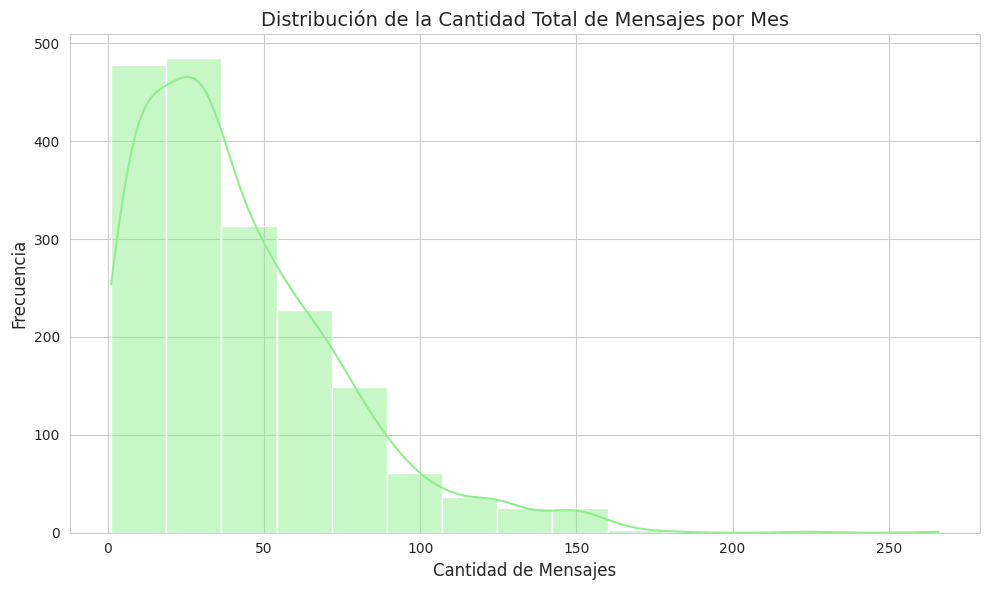

In [36]:
# Calcular la media y la varianza de los mensajes
mean_messages = user_data['total_messages'].mean()
variance_messages = user_data['total_messages'].var()

# Mostrar resultados
print(f"Media de mensajes enviados por mes: {mean_messages:.2f}")
print(f"Varianza de mensajes enviados por mes: {variance_messages:.2f}")

# Traza el histograma de la cantidad total de mensajes por mes
plt.figure(figsize=(10, 6))
sns.histplot(user_data['total_messages'], bins=15, kde=True, color='lightgreen')
plt.title('Distribución de la Cantidad Total de Mensajes por Mes', fontsize=14)
plt.xlabel('Cantidad de Mensajes', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.show()

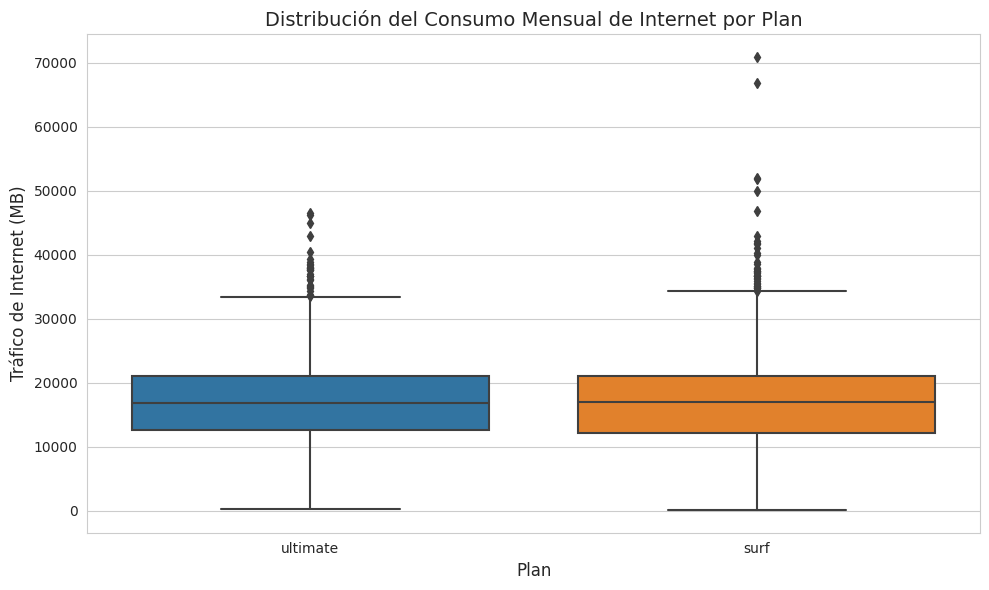

In [37]:
import pandas as pd

# Graficar con Seaborn un diagrama de caja
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='total_mb_used', data=user_data)
plt.title('Distribución del Consumo Mensual de Internet por Plan', fontsize=14)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('Tráfico de Internet (MB)', fontsize=12)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

Buen trabajo desarrollando el estudio y comparación de la distribuciones.   </div>

### Internet

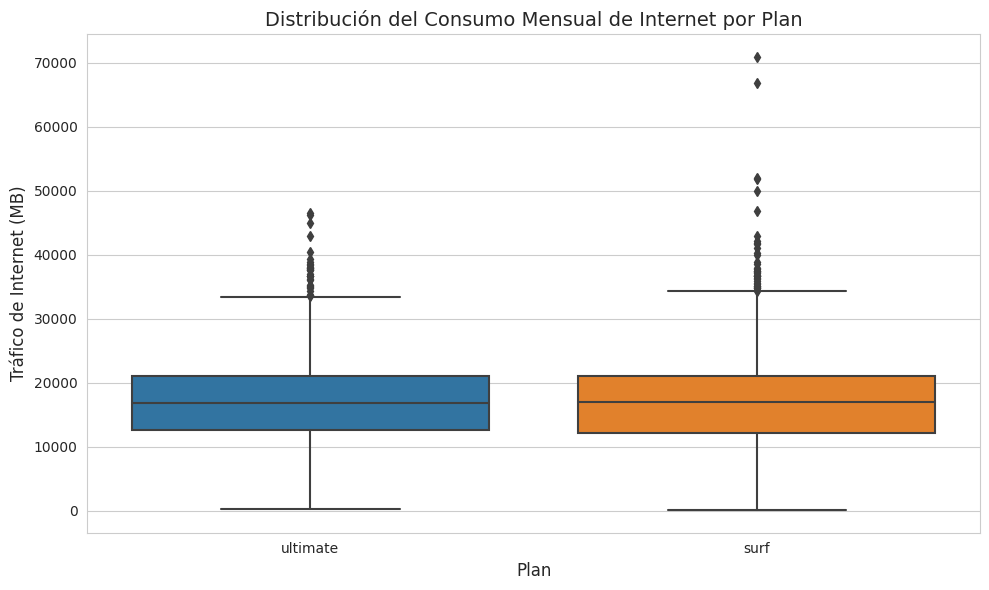

In [38]:
# Graficar con Seaborn un diagrama de caja para mostrar la distribución
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='total_mb_used', data=user_data)
plt.title('Distribución del Consumo Mensual de Internet por Plan', fontsize=14)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('Tráfico de Internet (MB)', fontsize=12)
plt.tight_layout()
plt.show()

Media del volumen de datos usados por mes (MB): 16882.20 MB
Varianza del volumen de datos usados por mes (MB): 61933513.55 MB²


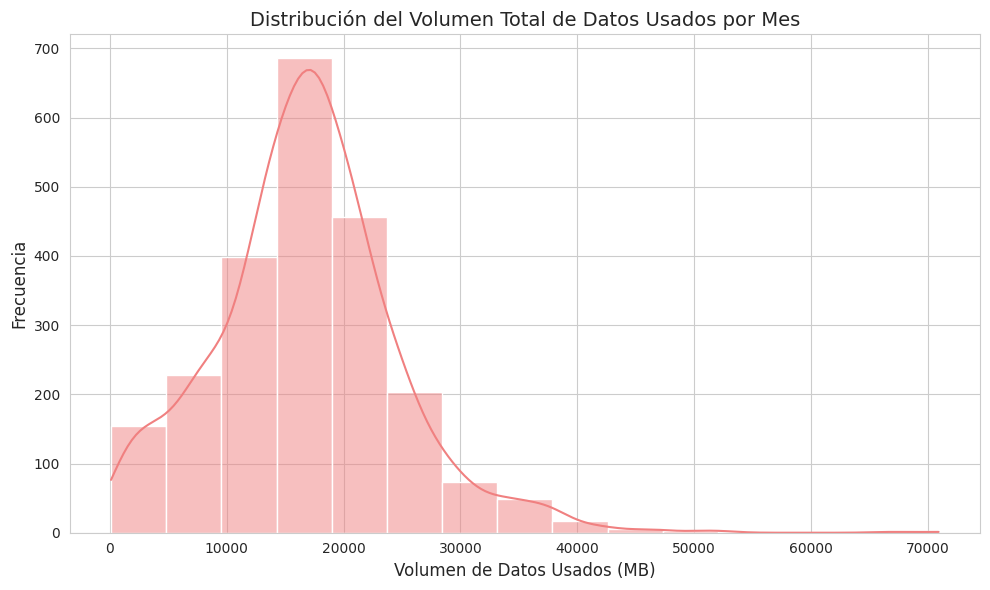

In [39]:
# Calcular la media y la varianza del volumen total de datos
mean_data_used = internet_grouped['total_mb_used'].mean()
variance_data_used = internet_grouped['total_mb_used'].var()

# Mostrar resultados
print(f"Media del volumen de datos usados por mes (MB): {mean_data_used:.2f} MB")
print(f"Varianza del volumen de datos usados por mes (MB): {variance_data_used:.2f} MB²")

# Traza el histograma del volumen total de datos usados por mes
plt.figure(figsize=(10, 6))

# Crear el histograma
sns.histplot(internet_grouped['total_mb_used'], bins=15, kde=True, color='lightcoral')

# Título y etiquetas
plt.title('Distribución del Volumen Total de Datos Usados por Mes', fontsize=14)
plt.xlabel('Volumen de Datos Usados (MB)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Las conclusiones sobre el comportamiento de los usuarios en relación con el consumo de tráfico de Internet son:

Consumo de datos: Los usuarios con el plan Ultimate, que incluye más datos, probablemente consuman más tráfico de Internet en comparación con los usuarios del plan Surf, que tienen una asignación más limitada.

Patrones de uso: Los usuarios de Ultimate pueden tener un uso más intensivo y frecuente de Internet, aprovechando la mayor capacidad de datos incluidos en su plan. En cambio, los usuarios de Surf pueden gestionar su uso de manera más controlada, evitando el excedente de datos.

Impacto de la tarifa: El plan Ultimate parece fomentar un consumo más alto y constante de Internet, mientras que los usuarios del plan Surf podrían ser más conscientes de sus límites de datos, llevando a un consumo más esporádico o moderado.

En resumen, sí, el comportamiento de consumo de Internet varía según el plan, con los usuarios de Ultimate consumiendo más datos en comparación con los usuarios de Surf, quienes tienen un consumo más contenido.

<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

Perfecto, Buen trabajo desarrollando el estudio de las distribuciones.    </div>

## Ingreso

Estadísticas del costo mensual por usuario:
count       371.000000
mean      27159.290423
std       44266.467882
min          20.000000
25%          20.000000
50%          70.070000
75%       40178.695000
max      225279.889500
Name: monthly_revenue, dtype: float64


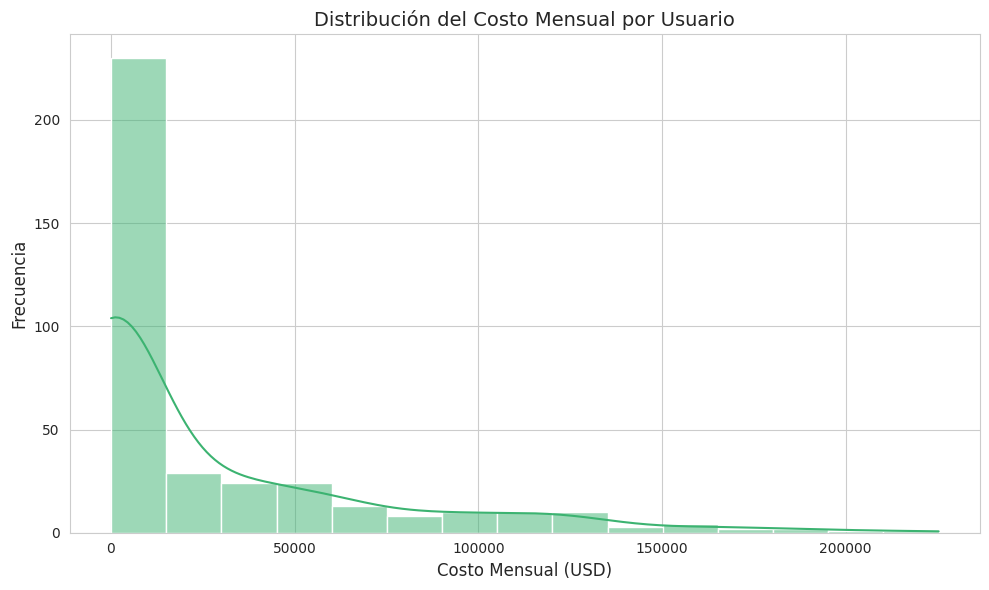

In [40]:
# Calcular estadísticas descriptivas
revenue_stats = user_data['monthly_revenue'].describe()
print("Estadísticas del costo mensual por usuario:")
print(revenue_stats)

# Crear el histograma
plt.figure(figsize=(10, 6))
sns.histplot(user_data['monthly_revenue'], bins=15, kde=True, color='mediumseagreen')

# Título y etiquetas
plt.title('Distribución del Costo Mensual por Usuario', fontsize=14)
plt.xlabel('Costo Mensual (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()


Diferencia en el precio mensual: El plan Ultimate tiene un costo mensual significativamente más alto (70 USD) en comparación con el plan Surf (20 USD), lo que genera una mayor fuente de ingresos por usuario para el plan Ultimate.

Usuarios y consumo: A pesar de la mayor tarifa mensual del plan Ultimate, es probable que los usuarios de este plan utilicen más servicios (datos, llamadas, mensajes), lo que podría justificar el costo más alto. Los usuarios de Surf, con un consumo más limitado, tienden a generar menos ingresos.

Impacto de la adopción de planes: Si la proporción de usuarios de Ultimate es menor que la de Surf, el ingreso total generado por el plan Ultimate puede ser más bajo debido a su menor base de usuarios, a pesar de su mayor tarifa mensual.

Ingresos por usuario: El ingreso promedio por usuario del plan Ultimate es mayor, pero esto dependerá de la cantidad total de usuarios de cada plan. El plan Surf genera menos ingresos por usuario, pero si tiene una mayor cantidad de suscriptores, puede compensar parcialmente esa diferencia.difiere el ingreso entre los planes.]

<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo desarrollando el estudio de la distribución.   </div>

## Prueba las hipótesis estadísticas

In [41]:
import scipy.stats as stats

# Filtrar los datos para los planes Ultimate y Surf
ultimate_users = user_data[user_data['plan'] == 'ultimate']['monthly_revenue']
ultimate_users = ultimate_users.fillna(0)
surf_users = user_data[user_data['plan'] == 'surf']['monthly_revenue']
surf_users = surf_users.fillna(0)

# Realizar la prueba t de Student para dos muestras independientes
t_stat, p_value = stats.ttest_ind(ultimate_users, surf_users, equal_var=True)

# Nivel de significancia
alpha = 0.05

# Resultado de la prueba
if p_value < alpha:
    print("Rechazamos la hipótesis nula: Los ingresos promedio son diferentes entre los planes Ultimate y Surf.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que los ingresos promedio son diferentes entre los planes Ultimate y Surf.")

# Mostrar resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar que los ingresos promedio son diferentes entre los planes Ultimate y Surf.
Estadístico t: 1.5511
Valor p: 0.1210


In [42]:
import scipy.stats as stats

# Filtrar los datos para los planes Ultimate y Surf
ultimate_users = user_data[user_data['plan'] == 'ultimate']['monthly_revenue']
ultimate_users = ultimate_users.fillna(0)
surf_users = user_data[user_data['plan'] == 'surf']['monthly_revenue']
surf_users = surf_users.fillna(0)

# Realizar la prueba t de Student para dos muestras independientes (varianzas desiguales)
t_stat, p_value = stats.ttest_ind(ultimate_users, surf_users, equal_var=False)

# Imprimir los resultados
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

# Definir el valor alfa
alpha = 0.05

# Decisión de rechazo de la hipótesis nula
if p_value < alpha:
    print("Rechazamos la hipótesis nula. Los ingresos promedio de los planes Ultimate y Surf son diferentes.")
else:
    print("No rechazamos la hipótesis nula. No hay evidencia suficiente para afirmar que los ingresos promedio son diferentes.")

Estadístico t: 1.4152
Valor p: 0.1573
No rechazamos la hipótesis nula. No hay evidencia suficiente para afirmar que los ingresos promedio son diferentes.


<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

Buen trabajo con el despliegue de las pruebas.  </div>

## Conclusión general

A lo largo del proyecto, se han analizado diversos aspectos del comportamiento de los usuarios de los planes *Ultimate* y *Surf* de Megaline, incluyendo el uso de llamadas, mensajes e internet, así como la influencia de estos factores en los ingresos generados por cada usuario. Se realizaron análisis estadísticos, incluyendo la comparación de ingresos entre ambos planes mediante una prueba t de Student, la cual mostró que no hay evidencia suficiente para afirmar que los ingresos promedio de los planes sean diferentes.

El análisis también permitió entender mejor la distribución del consumo y los patrones de comportamiento de los usuarios, proporcionando información clave para futuras decisiones estratégicas en cuanto a precios, segmentación de clientes y optimización de los servicios ofrecidos. Esto contribuye a una mejor comprensión de los factores que influyen en los ingresos y ofrece bases sólidas para la mejora continua de los planes tarifarios de la empresa.


<div class="alert alert-block alert-success">
<b>Comentario del revisor #6</b> <a class="tocSkip"></a>  

Perfecto, buen trabajo estructurando la sección de conclusiones finales.   </div>